In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('startup_funding.csv')

In [3]:
pd.reset_option('display.max_rows')


In [4]:
# shape od data
print(f'Dataset has {df.shape[0]} rows and {df.shape[1]} columns')


Dataset has 3044 rows and 10 columns


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3020 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB


In [6]:
# columns
df.columns

Index(['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical',
       'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType',
       'Amount in USD', 'Remarks'],
      dtype='object')

## Dimension Columns
    1.Sr No
    2.Date
    3.Startup Name
    4.Industry Vertical
    5.SubVertical
    6.City
    7.Investors Name
    8.InvestmentnType
## Measure Columns
    1.Amount_USD



# **Data cleaning**

In [7]:
df.sample(5)

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
1352,1353,07/09/2016,Simplilearn,Education,Online Certification programs,Bangalore,InnoVen Capital India,Private Equity,"60,00,000",NaN
1701,1702,12/05/2016,Galleri5,Consumer Internet,Visual Content Discovery platform,Bangalore,"Phanindra Sama, Raghunandan G,",Seed Funding,NaN,NaN
3033,3034,22/01/2015,Caratlane.com,NaN,NaN,NaN,Tiger Global,Private Equity,"3,10,00,000",Series D
270,271,23/05/2018,Aashiyaan,Finance,Housing Finance For Low-Income Families,Kolkata,"Insistor, Oikocredit",Seed/ Angel Funding,"20,00,000",NaN
829,830,18/05/2017,PumpKart,eCommerce,Online Water Pumps etailer,Chandigarh,Dr. Ritesh Malik,Seed Funding,NaN,NaN


# **Obervations**
    1.Rename columns
    2.Drop column - Remark ,sr_no
    3.Treat null values

###  Column wise issue
    1.date -- convert it into date dtype
    2.investorname -- tideness issue
    3.amount_USD -- convert it into integer dtype




### ***Data Cleaning***

In [8]:
# dropping Remarks column
df = df.drop(columns=['Remarks','Sr No'])

In [9]:
# renameing columns
df.columns =  ['date', 'startup_name', 'industry_verticle',
               'subvertical', 'city_location', 'investor_names', 'investment_type',
       'amount_USD']

In [10]:
df.sample(1)

,date,startup_name,industry_verticle,subvertical,city_location,investor_names,investment_type,amount_USD
1611,16/06/2016,Athletto,Consumer Internet,Sports Venue discovery and booking platform,Bangalore,Atul Ingle,Seed Funding,NaN


In [11]:
# issue at row while converting into date dtype
df[df['date'] == '05/072018']

,date,startup_name,industry_verticle,subvertical,city_location,investor_names,investment_type,amount_USD
192,05/072018,Loan Tap,Consumer Internet,Online Lending Platform For Salaried Professio...,Mumbai,"Shunwei Capital, Tuscan Ventures, Ashish Goenk...",Private Equity,"62,50,000"


In [12]:
df.loc[192,'date'] = '05/07/2018'

In [13]:
df[df['date'] == '01/07/015']

,date,startup_name,industry_verticle,subvertical,city_location,investor_names,investment_type,amount_USD
2571,01/07/015,HandyHome,Hyperlocal Electronics repair Service,NaN,Mumbai,"Bessemer Ventures, Kae Capital",Seed Funding,"6,30,000"


In [14]:
df.loc[2571,'date'] = '01/07/2015'

In [15]:
# converting date column into date dtype
df['date'] = pd.to_datetime(df['date'],format='mixed',errors='coerce')

In [16]:
# this will create issue while converting into intger dtype so remove it becauze amount is disclose so it will not helps to analyze it
df[(df['amount_USD'] == 'undisclosed') | (df['amount_USD'] == 'unknown') | (df['amount_USD'] == 'Undisclosed') | (df['amount_USD'] == 'Unknown')]

,date,startup_name,industry_verticle,subvertical,city_location,investor_names,investment_type,amount_USD
20,2019-11-17,Burger Singh,Food and Beverage,Indian Burger Brand,Gurgaon,RB Investments,Venture,undisclosed
34,2019-10-21,The Man Company,Consumer Goods,Beauty and Grooming,Gurgaon,Ayushmann Khurana,Corporate Round,unknown
58,2019-08-19,Mishry Reviews,Services,Product Review,Gurgaon,Vir Sanghvi,Series A,Undisclosed
89,2019-06-05,Ola Electric,Transport,Cabs,Bengaluru,Tata Sons,Series A,undisclosed
91,2019-05-05,StyleDotMe,E-commerce,Fashion and Shopping,Delhi,Indian Angel Network and other angel investors...,Bridge Round,undisclosed
112,2019-01-02,FleetX,AI,Logistics,Gurgaon,India Quotient and LetsVenture\\xe2\\x80\\x99s...,Pre Series A,Undisclosed
139,2018-11-22,Skillbox,Social Network,Art,Gurugram,Individual investors,Seed Funding,Undisclosed


In [17]:
df[df['city_location'].str.contains('Mumbai', na=False)]

,date,startup_name,industry_verticle,subvertical,city_location,investor_names,investment_type,amount_USD
4,2020-02-01,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"
13,2019-12-16,InCred,Finance,Non-Banking Financial Company,Mumbai,NaN,Debt Funding,"59,00,000"
28,2019-11-18,Medikabazaar,Healthcare,B2B platform for medical supplies,Mumbai,"Ackermans & van Haaren, HealthQuad, Rebright P...",Series B,"1,58,00,000"
36,2019-04-09,Cashflo,FinTech,Invoice discounting platform and SME lending m...,Mumbai,SAIF Partners,Series A,"33,00,000"
37,2019-04-09,Digital F5,"Advertising, Marketing",Digital marketing firm,Mumbai,TIW Private Equity,Private Equity Round,"60,00,000"
...,...,...,...,...,...,...,...,...
2841,2015-04-18,Doormint,On-Demand Handyman Services,NaN,Mumbai,Powai Lake Ventures,Seed Funding,NaN
2851,2015-04-23,Craftstvilla,Ethnic Product eCommerce,NaN,Mumbai,"Sequoia Capital, Nexus venture Partners, Light...",Private Equity,"1,80,00,000"
2857,2015-04-24,Coverfox,Online Insurance Aggregator,NaN,Mumbai,"Accel US, Accel India, SAIF Partners.",Private Equity,"1,20,00,000"
2859,2015-04-27,Grab,Food Logistics & Delivery,NaN,Mumbai,"Oliphans Capital, Haresh Chawla",Seed Funding,"10,00,000"


In [19]:
df.drop([20,34,58,89,91,112,139],inplace=True)

In [20]:
# cleaning amount_USD column
df['amount_USD'] = df['amount_USD'].str.replace(',','').str.replace('+','').str.replace('\\\\xc2\\\\xa0','').str.replace('N/A','NaN').astype(float)

In [21]:
# cleaning city column
df['city_location'] = df['city_location'].str.replace('\u00A0', '', regex=False)
df['city_location'] = df['city_location'].str.strip()
df['city_location'] = df['city_location'].str.replace('New Delhi','New Delhi').str.replace('Bangalore','Bangalore').str.replace('Mumbai','Mumbai').str.replace('\\xc2\\xa0Bangalore','Bangalore').str.replace(u'\xa0', ' ', regex=True).str.strip()


In [22]:
# city_locaion
city = df['city_location'].value_counts()

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3037 entries, 0 to 3043
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               3035 non-null   datetime64[ns]
 1   startup_name       3037 non-null   object        
 2   industry_verticle  2866 non-null   object        
 3   subvertical        2101 non-null   object        
 4   city_location      2857 non-null   object        
 5   investor_names     3013 non-null   object        
 6   investment_type    3033 non-null   object        
 7   amount_USD         2073 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 213.5+ KB


In [24]:
# checking duplicate rows
df.duplicated().sum()

np.int64(0)

In [25]:
# checking null values
df.isna().sum()

,0
date,2
startup_name,0
industry_verticle,171
subvertical,936
city_location,180
investor_names,24
investment_type,4
amount_USD,964


In [26]:
df = df.sort_values('date').reset_index(drop=True)

In [27]:
df[df['date'].isna()]

,date,startup_name,industry_verticle,subvertical,city_location,investor_names,investment_type,amount_USD
3035,NaT,\\xc2\\xa0Infinity Assurance,\\xc2\\xa0Warranty Programs Service Administra...,NaN,\\xc2\\xa0New Delhi,\\xc2\\xa0Indian Angel Network,Seed Funding,600000.0
3036,NaT,Corporate360,NaN,NaN,NaN,Group of Angel Investors,Seed Funding,200000.0


In [28]:
df = df.drop([3035,3036])

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               3035 non-null   datetime64[ns]
 1   startup_name       3035 non-null   object        
 2   industry_verticle  2865 non-null   object        
 3   subvertical        2101 non-null   object        
 4   city_location      2856 non-null   object        
 5   investor_names     3011 non-null   object        
 6   investment_type    3031 non-null   object        
 7   amount_USD         2071 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 189.8+ KB


In [30]:
# all have nan values in the
df[df['industry_verticle'].isna()]

,date,startup_name,industry_verticle,subvertical,city_location,investor_names,investment_type,amount_USD
37,2015-01-13,AppVirality,NaN,NaN,NaN,"Rajan Anandan, Mike Galgon, Ashim Mehra, Mohit...",Seed Funding,NaN
38,2015-01-14,RateGain,NaN,NaN,NaN,TA Associates,Private Equity,50000000.0
39,2015-01-15,Wishberry,NaN,NaN,NaN,"Rajan Anandan, Shankar Mahadevan, Deep Kalra &...",Seed Funding,650000.0
40,2015-01-16,eKincare,NaN,NaN,NaN,Adroitent Pvt. Ltd.,Seed Funding,161000.0
41,2015-01-18,ShopClues,NaN,NaN,NaN,Tiger Global & Other investors,Private Equity,100000000.0
...,...,...,...,...,...,...,...,...
869,2015-12-01,Verayu,NaN,NaN,NaN,"GWB Group, Blume Ventures",Private Equity,NaN
870,2015-12-02,Stayzilla,NaN,NaN,NaN,"Nexus Venture Partners, Matrix Partners",Private Equity,20000000.0
871,2015-12-02,Practo,NaN,NaN,NaN,"Sequoia Capital, Matrix Partners",Private Equity,30000000.0
872,2015-12-03,MoonFrog Labs,NaN,NaN,NaN,"Tiger Global, Sequoia Capital.",Private Equity,15000000.0


In [31]:
df.fillna(np.nan,inplace=True)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               3035 non-null   datetime64[ns]
 1   startup_name       3035 non-null   object        
 2   industry_verticle  2865 non-null   object        
 3   subvertical        2101 non-null   object        
 4   city_location      2856 non-null   object        
 5   investor_names     3011 non-null   object        
 6   investment_type    3031 non-null   object        
 7   amount_USD         2071 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 189.8+ KB


# **Exploratory Data Analysis (EDA)**

In [33]:
# year wise amount invested in indian startup
year = df['date'].dt.year

In [34]:
df.insert(1,'year',year)

In [35]:
df

,date,year,startup_name,industry_verticle,subvertical,city_location,investor_names,investment_type,amount_USD
0,2015-01-05,2015,Foodpanda,Online Food Delivery,NaN,Gurgaon,"Goldman Sachs, Rocket Internet",Private Equity,100000000.0
1,2015-01-05,2015,Termsheet,Fund Raising Platform,NaN,Chennai,"Anand Vijay, Nipun Dureja, Satyajit Heeralal, ...",Seed Funding,100000.0
2,2015-01-06,2015,Proviera,Probiotic Technology Products Manufacturer,NaN,Chennai,Infuse Ventures,Private Equity,550000.0
3,2015-01-06,2015,Glamrs,Online Fashion Video Portal,NaN,Mumbai,"Ventureworks India, Blume Ventures, Batlivala ...",Private Equity,1000000.0
4,2015-01-06,2015,CredR,Used two-wheeler Marketplace,NaN,Mumbai,GrowthStory,Seed Funding,NaN
...,...,...,...,...,...,...,...,...,...
3030,2020-02-01,2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,1800000.0
3031,2020-02-01,2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,3000000.0
3032,2020-09-01,2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,18358860.0
3033,2020-09-01,2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,200000000.0


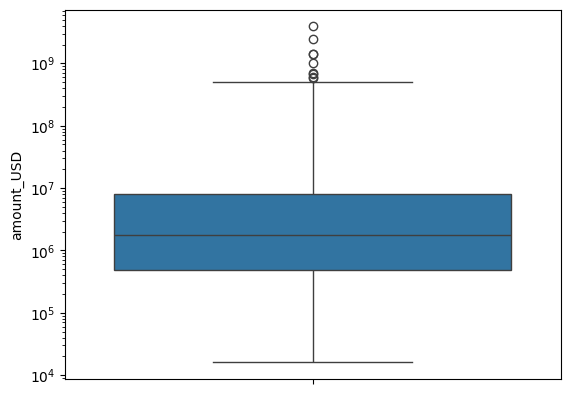

In [36]:
sns.boxplot(df['amount_USD'],log_scale=True)
plt.savefig("box_plot.png",dpi=300,bbox_inches='tight')

### ***Yearly Funding Trend***

In [37]:
temp_df = df.groupby('year')['amount_USD'].sum().reset_index()

In [38]:
temp_df

,year,amount_USD
0,2015,8.672222e+09
1,2016,3.828089e+09
2,2017,1.042931e+10
3,2018,5.122368e+09
4,2019,9.700919e+09
5,2020,3.902073e+08


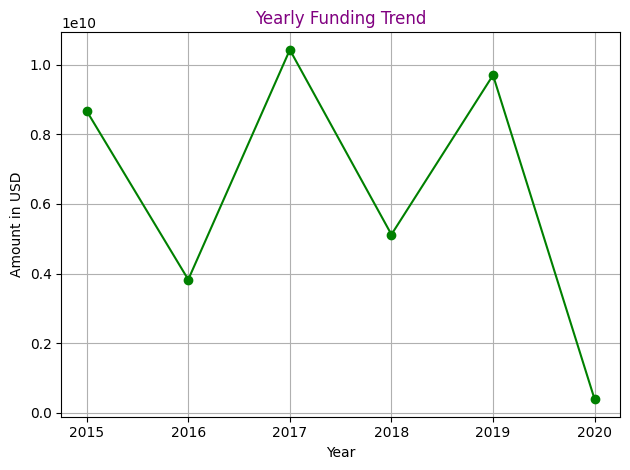

In [39]:
plt.plot(temp_df['year'],temp_df['amount_USD'],color='green',marker='o')
plt.title('Yearly Funding Trend',color='purple')
plt.xlabel('Year')
plt.ylabel('Amount in USD')
plt.grid(True)
plt.tight_layout()
plt.savefig("Funding Trend",dpi=300,bbox_inches='tight')

### ***Top 5 Industries by Funding***

In [40]:
# industry wise funding
temp_df = df.groupby('industry_verticle')['amount_USD'].sum().reset_index().sort_values('amount_USD',ascending=False)

In [41]:
# temp_df

In [42]:
# top 5 industries with largest investment
top_5 = temp_df.iloc[0:5]

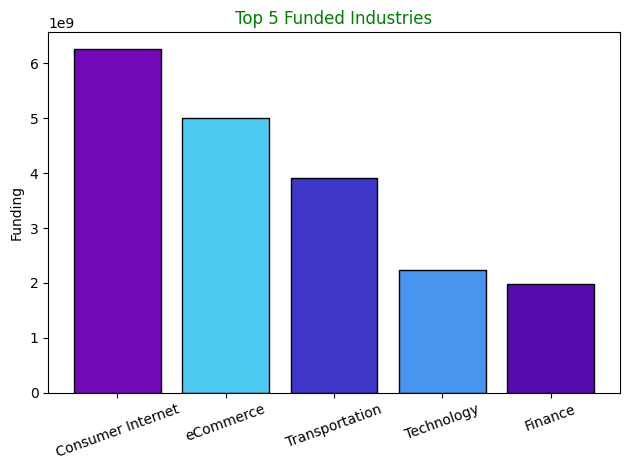

In [43]:
plt.bar(top_5['industry_verticle'],top_5['amount_USD'],color=['#7209B7','#4CC9F0','#3F37C9','#4895EF','#560BAD'],edgecolor='black')
plt.title('Top 5 Funded Industries',color='green')
plt.ylabel('Funding')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("Industry Funding.png",dpi=300,bbox_inches='tight')

### ***City Wise Funding***

In [44]:
df['city_location'] = df['city_location'].str.replace(r'\\xc2\\xa0', '', regex=True)

In [45]:
df['city_location'] = df['city_location'].str.replace(r'\\xc2\\xa0', '', regex=True)

In [46]:
df['city_location'] = df['city_location'].str.replace('Bengaluru','Bangalore').str.split('/').str[0]

In [47]:
top_3_city = df.groupby('city_location')['amount_USD'].sum().reset_index().sort_values(['amount_USD','city_location'],ascending=False).iloc[0:3]

In [49]:
df['city_location'].value_counts()

,count
city_location,
Bangalore,842
Mumbai,569
New Delhi,422
Gurgaon,283
Pune,106
...,...
Haryana,1
Andheri,1
Amritsar,1


In [67]:
df['city_location'] = df['city_location'].str.replace('Bengaluru','Bangalore').str.split('/').str[0]
city = df['city_location'].value_counts()

fig = px.bar(city,x=city.index[:10],y=city.values[:10],color=city.index[:10],title='City With Funded Startups',text_auto=True)
fig.update_xaxes(title='City')
fig.update_yaxes(title='Count')
fig.show()

Text(0, 0.5, 'Funding')

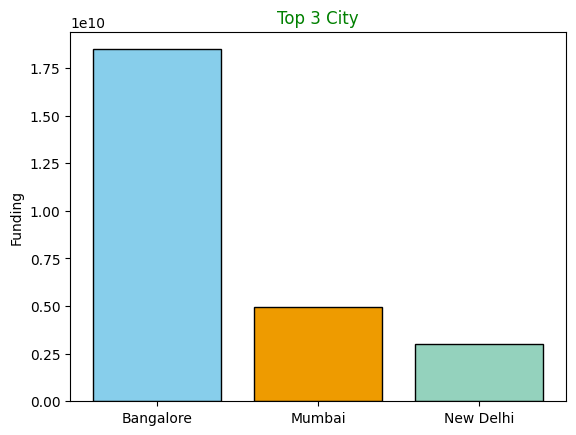

In [51]:
plt.bar(top_3_city['city_location'],top_3_city['amount_USD'],color=['skyblue', '#EE9B00', '#94D2BD'],edgecolor='black')
plt.title('Top 3 City',color='green')
plt.ylabel('Funding')

In [52]:
investor = df.groupby('investor_names')['amount_USD'].sum().reset_index().sort_values('amount_USD',ascending=False).iloc[0:3]

In [53]:
df

,date,year,startup_name,industry_verticle,subvertical,city_location,investor_names,investment_type,amount_USD
0,2015-01-05,2015,Foodpanda,Online Food Delivery,NaN,Gurgaon,"Goldman Sachs, Rocket Internet",Private Equity,100000000.0
1,2015-01-05,2015,Termsheet,Fund Raising Platform,NaN,Chennai,"Anand Vijay, Nipun Dureja, Satyajit Heeralal, ...",Seed Funding,100000.0
2,2015-01-06,2015,Proviera,Probiotic Technology Products Manufacturer,NaN,Chennai,Infuse Ventures,Private Equity,550000.0
3,2015-01-06,2015,Glamrs,Online Fashion Video Portal,NaN,Mumbai,"Ventureworks India, Blume Ventures, Batlivala ...",Private Equity,1000000.0
4,2015-01-06,2015,CredR,Used two-wheeler Marketplace,NaN,Mumbai,GrowthStory,Seed Funding,NaN
...,...,...,...,...,...,...,...,...,...
3030,2020-02-01,2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,1800000.0
3031,2020-02-01,2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,3000000.0
3032,2020-09-01,2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bangalore,Sequoia Capital India,Series B,18358860.0
3033,2020-09-01,2020,BYJU’S,E-Tech,E-learning,Bangalore,Tiger Global Management,Private Equity Round,200000000.0


### ***Top Investment Type***

In [54]:
df['investment_type'] = df['investment_type'].str.lower()

In [55]:
temp_df = df[df['investment_type'].str.contains('seed', na=False)]

In [56]:
df.loc[temp_df.index,'investment_type'] = 'Seed Funding'

In [57]:
temp_df = df[df['investment_type'].str.contains('equity', na=False)]

In [58]:
df.loc[temp_df.index,'investment_type'] = 'Private equity'

In [59]:
df['investment_type'] = df['investment_type'].str.title()

In [60]:
top_type = df['investment_type'].value_counts().iloc[:5]

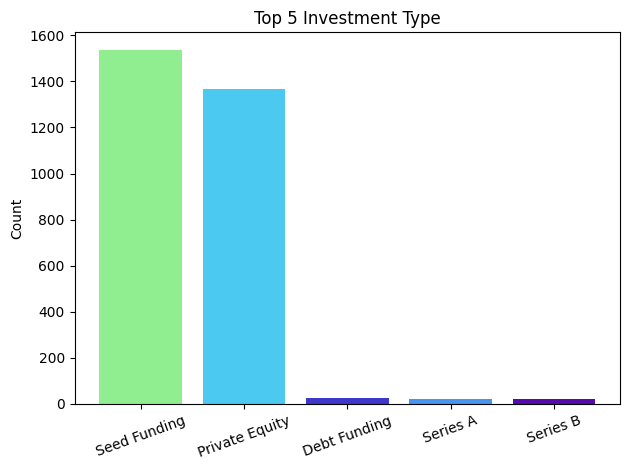

In [61]:
plt.bar(top_type.index,top_type.values,color=['lightgreen','#4CC9F0','#3F37C9','#4895EF','#560BAD'])
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.title('Top 5 Investment Type')
plt.tight_layout()
plt.savefig("top 5 investment_type.png",dpi=300,bbox_inches='tight')

In [62]:
temp_df = df.groupby('date')['amount_USD'].sum().reset_index()

In [63]:
# investment graph
px.line(temp_df,temp_df['date'],temp_df['amount_USD'],title='Funding Trend')